In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
df_final=pd.read_csv('../data_processed/df_final.csv')

In [132]:
df_final.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente
0,1001,KILLINJ,F,2001,10,1001.0,Agliè,"13,1462",2545.0
1,1001,KILLINJ,F,2002,10,1001.0,Agliè,"13,1462",2545.0
2,1001,KILLINJ,F,2003,7,1001.0,Agliè,"13,1462",2545.0
3,1001,KILLINJ,F,2004,13,1001.0,Agliè,"13,1462",2545.0
4,1001,KILLINJ,F,2005,2,1001.0,Agliè,"13,1462",2545.0


In [133]:
df_final.isnull().sum()

REF_AREA                        0
DATA_TYPE                       0
RESULT                          0
TIME_PERIOD                     0
OBS_VALUE                       0
Codice Comune (numerico)    24867
Comune                      24939
Superficie (Kmq)            24867
Popolazione residente       24867
dtype: int64

In [134]:
df_final['DATA_TYPE'].value_counts()

DATA_TYPE
KILLINJ    382368
ROADACC    191184
Name: count, dtype: int64

In [135]:
df_final['RESULT'].value_counts()

RESULT
F    191184
M    191184
9    191184
Name: count, dtype: int64

In [136]:
trend = df_final.groupby('TIME_PERIOD')['OBS_VALUE'].sum()

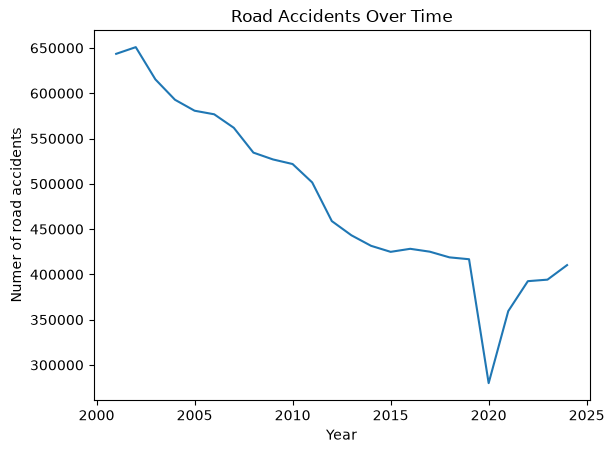

In [137]:
plt.plot(trend.index, trend.values)
plt.title('Road Accidents Over Time')
plt.xlabel('Year')
plt.ylabel('Numer of road accidents')
plt.show()

In [138]:
top_comuni = (df_final
              .groupby('Comune')['OBS_VALUE']
              .sum().
              sort_values(ascending=False)
              .head(10)
              )

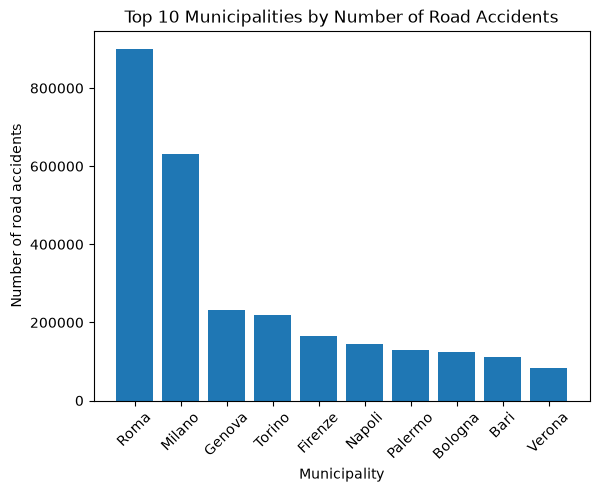

In [139]:
plt.bar(top_comuni.index, top_comuni.values)
plt.title('Top 10 Municipalities by Number of Road Accidents')
plt.xlabel('Municipality')
plt.ylabel('Number of road accidents')
plt.xticks(rotation=45)
plt.show()

In [140]:
df_final['Road_accident_per_resident'] = (
    df_final['OBS_VALUE']
    /
    df_final['Popolazione residente']
)

In [141]:
top_pop = (df_final
              .groupby('Comune')['Road_accident_per_resident']
              .mean()
              .sort_values(ascending=False)
              .head(10)
              )

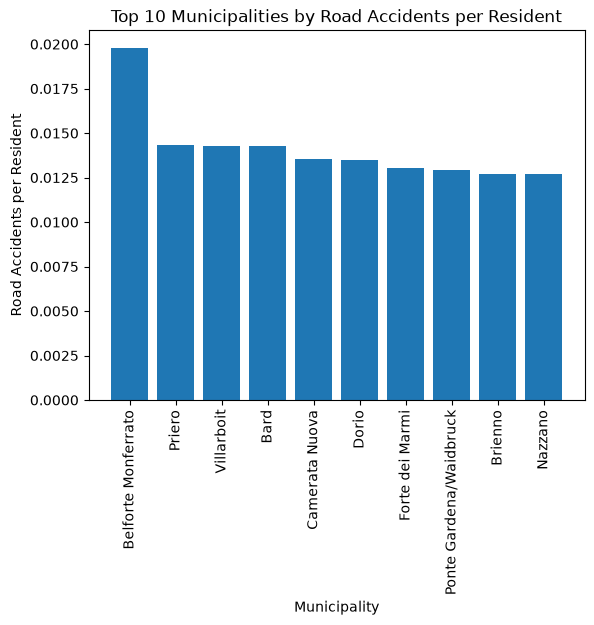

In [142]:
plt.bar( top_pop.index, top_pop.values)
plt.title('Top 10 Municipalities by Road Accidents per Resident')
plt.xlabel('Municipality')
plt.ylabel('Road Accidents per Resident')
plt.xticks(rotation=90)
plt.show()

In [143]:
df_final['Superficie (Kmq)'] = df_final['Superficie (Kmq)'].str.replace(',','.', regex=False)

In [144]:
df_final['Superficie (Kmq)'] = pd.to_numeric(
    df_final['Superficie (Kmq)'],
    errors='coerce'
)

In [145]:
df_final['Road_accident_per_Kmq'] = (
    df_final['OBS_VALUE']
    /
    df_final['Superficie (Kmq)']
)

In [146]:
top_density = (df_final
              .groupby('Comune')['Road_accident_per_Kmq']
              .mean()
              .sort_values(ascending=False)
              .head(10)
              )

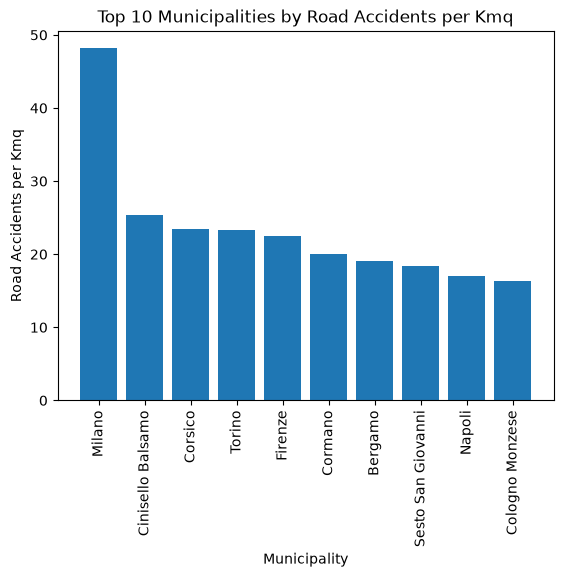

In [147]:
plt.bar( top_density.index, top_density.values)
plt.title('Top 10 Municipalities by Road Accidents per Kmq')
plt.xlabel('Municipality')
plt.ylabel('Road Accidents per Kmq')
plt.xticks(rotation=90)
plt.show()

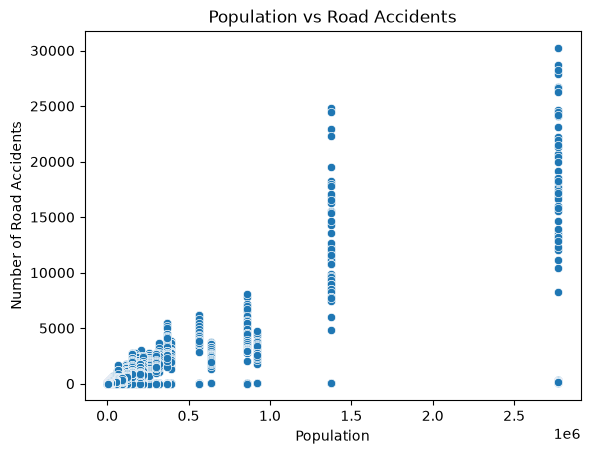

In [148]:
sns.scatterplot(
    data=df_final,
    x='Popolazione residente',
    y='OBS_VALUE'
)
plt.title('Population vs Road Accidents')
plt.xlabel('Population')
plt.ylabel('Number of Road Accidents')
plt.show()

In [149]:
df_final.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente,Road_accident_per_resident,Road_accident_per_Kmq
0,1001,KILLINJ,F,2001,10,1001.0,Agliè,13.1462,2545.0,0.003929,0.760676
1,1001,KILLINJ,F,2002,10,1001.0,Agliè,13.1462,2545.0,0.003929,0.760676
2,1001,KILLINJ,F,2003,7,1001.0,Agliè,13.1462,2545.0,0.002750,0.532473
3,1001,KILLINJ,F,2004,13,1001.0,Agliè,13.1462,2545.0,0.005108,0.988879
4,1001,KILLINJ,F,2005,2,1001.0,Agliè,13.1462,2545.0,0.000786,0.152135


In [152]:
df_final.to_csv("../data_processed/df_final.csv", index=False)